# Reddit Data Preprocessing

Preprocesses Reddit Ethereum posts and comments into daily aggregated features.
Includes visualization to determine optimal date filtering.

**Features extracted:**
- Daily activity counts (posts, comments)
- Sentiment statistics (mean, std)
- Fraud keyword mentions
- Engagement scores

In [1]:
import pandas as pd
import re
import os

In [2]:
posts_path = '../data/raw/reddit/the-reddit-ethereum-dataset-posts.csv'
comments_path = '../data/raw/reddit/the-reddit-ethereum-dataset-comments.csv'

In [3]:
posts = pd.read_csv(posts_path)
print(f"Posts: {posts.shape}")

comments = pd.read_csv(comments_path)
print(f"Comments: {comments.shape}")

Posts: (479260, 12)
Comments: (1132331, 10)


## Explore Data

In [4]:
print("=== Posts Overview ===")
print(f"Shape: {posts.shape}")
print(f"\nColumns: {posts.columns.tolist()}")
print(f"\nData types:\n{posts.dtypes}")
print(f"\nSample:")
posts.head(2)

=== Posts Overview ===
Shape: (479260, 12)

Columns: ['type', 'id', 'subreddit.id', 'subreddit.name', 'subreddit.nsfw', 'created_utc', 'permalink', 'domain', 'url', 'selftext', 'title', 'score']

Data types:
type              object
id                object
subreddit.id      object
subreddit.name    object
subreddit.nsfw      bool
created_utc        int64
permalink         object
domain            object
url               object
selftext          object
title             object
score              int64
dtype: object

Sample:


,type,id,subreddit.id,subreddit.name,subreddit.nsfw,created_utc,permalink,domain,url,selftext,title,score
0,post,qkrfg9,2qiux,riddles,False,1635811168,https://old.reddit.com/r/riddles/comments/qkrf...,self.riddles,NaN,[removed],Ethereum Extasy SOMEONE PLEASE SOLVE THIS FOR ...,0
1,post,qkr8mn,2ruj5,xrp,False,1635810613,https://old.reddit.com/r/XRP/comments/qkr8mn/a...,self.xrp,NaN,[removed],Anyone have any insight on the Davis Schwartz ...,1


In [5]:
print("=== Comments Overview ===")
print(f"Shape: {comments.shape}")
print(f"\nColumns: {comments.columns.tolist()}")
print(f"\nSentiment stats:\n{comments['sentiment'].describe()}")
print(f"\nSentiment null count: {comments['sentiment'].isna().sum()} ({comments['sentiment'].isna().mean()*100:.2f}%)")

=== Comments Overview ===
Shape: (1132331, 10)

Columns: ['type', 'id', 'subreddit.id', 'subreddit.name', 'subreddit.nsfw', 'created_utc', 'permalink', 'body', 'sentiment', 'score']

Sentiment stats:
count    1.101534e+06
mean     3.231925e-01
std      5.323997e-01
min     -9.998000e-01
25%      0.000000e+00
50%      4.200000e-01
75%      8.009000e-01
max      1.000000e+00
Name: sentiment, dtype: float64

Sentiment null count: 30797 (2.72%)


## Convert Timestamps to Daily Date

In [6]:
posts['day'] = pd.to_datetime(posts['created_utc'], unit='s', utc=True).dt.date
comments['day'] = pd.to_datetime(comments['created_utc'], unit='s', utc=True).dt.date

posts['day'] = pd.to_datetime(posts['day'])
comments['day'] = pd.to_datetime(comments['day'])

print(f"Posts date range: {posts['day'].min()} to {posts['day'].max()}")
print(f"Comments date range: {comments['day'].min()} to {comments['day'].max()}")

Posts date range: 2011-07-03 00:00:00 to 2021-11-01 00:00:00
Comments date range: 2011-05-25 00:00:00 to 2021-11-01 00:00:00


## Extract Fraud Keyword Mentions

In [7]:
fraud_keywords = [
    'scam', 'scammer', 'phishing', 'fraud', 'fraudulent',
    'hack', 'hacked', 'hacker', 'stolen', 'theft',
    'rug pull', 'rugpull', 'rug-pull', 'exploit', 'exploited',
    'malicious', 'ponzi', 'pyramid', 'attack', 'breach',
    'compromised', 'drain', 'drained', 'suspicious', 'warning',
    'fake', 'honeypot', 'exit scam'
]

fraud_pattern = re.compile('|'.join(fraud_keywords), re.IGNORECASE)

# Combine text fields for posts
posts['text'] = (posts['title'].fillna('') + ' ' + posts['selftext'].fillna('')).str.lower()
comments['text'] = comments['body'].fillna('').astype(str).str.lower()

# Flag fraud mentions
posts['has_fraud_mention'] = posts['text'].str.contains(fraud_pattern, na=False).astype(int)
comments['has_fraud_mention'] = comments['text'].str.contains(fraud_pattern, na=False).astype(int)

print(f"Posts with fraud keywords: {posts['has_fraud_mention'].sum()} ({posts['has_fraud_mention'].mean()*100:.2f}%)")
print(f"Comments with fraud keywords: {comments['has_fraud_mention'].sum()} ({comments['has_fraud_mention'].mean()*100:.2f}%)")

Posts with fraud keywords: 15562 (3.25%)
Comments with fraud keywords: 84322 (7.45%)


## Aggregate to Daily Level

In [8]:
# Posts daily aggregation
posts_daily = posts.groupby('day').agg(
    reddit_post_count=('id', 'count'),
    reddit_post_avg_score=('score', 'mean'),
    reddit_post_fraud_count=('has_fraud_mention', 'sum')
).reset_index()

# Comments daily aggregation
comments_daily = comments.groupby('day').agg(
    reddit_comment_count=('id', 'count'),
    reddit_comment_avg_score=('score', 'mean'),
    reddit_comment_fraud_count=('has_fraud_mention', 'sum'),
    reddit_avg_sentiment=('sentiment', 'mean'),
    reddit_sentiment_std=('sentiment', 'std')
).reset_index()

print(f"Posts daily: {posts_daily.shape}")
print(f"Comments daily: {comments_daily.shape}")

Posts daily: (2807, 4)
Comments daily: (2883, 6)


## Merge Posts and Comments Daily Features


In [9]:
# Merge posts and comments
reddit_daily = pd.merge(posts_daily, comments_daily, on='day', how='outer')
reddit_daily = reddit_daily.sort_values('day').reset_index(drop=True)

# Fill missing counts with 0
count_cols = ['reddit_post_count', 'reddit_comment_count', 
              'reddit_post_fraud_count', 'reddit_comment_fraud_count']
reddit_daily[count_cols] = reddit_daily[count_cols].fillna(0).astype(int)

# Create combined features
reddit_daily['reddit_total_activity'] = reddit_daily['reddit_post_count'] + reddit_daily['reddit_comment_count']
reddit_daily['reddit_total_fraud_mentions'] = reddit_daily['reddit_post_fraud_count'] + reddit_daily['reddit_comment_fraud_count']
reddit_daily['reddit_fraud_mention_ratio'] = (
    reddit_daily['reddit_total_fraud_mentions'] / reddit_daily['reddit_total_activity']
).fillna(0)

print(f"Merged daily shape: {reddit_daily.shape}")
print(f"Date range: {reddit_daily['day'].min()} to {reddit_daily['day'].max()}")
reddit_daily.head()

Merged daily shape: (2886, 12)
Date range: 2011-05-25 00:00:00 to 2021-11-01 00:00:00


,day,reddit_post_count,reddit_post_avg_score,reddit_post_fraud_count,reddit_comment_count,reddit_comment_avg_score,reddit_comment_fraud_count,reddit_avg_sentiment,reddit_sentiment_std,reddit_total_activity,reddit_total_fraud_mentions,reddit_fraud_mention_ratio
0,2011-05-25,0,NaN,0,1,3.0,0,-0.4871,NaN,1,0,0.0
1,2011-06-14,0,NaN,0,1,1.0,0,0.9300,NaN,1,0,0.0
2,2011-07-03,1,0.0,0,1,1.0,0,0.0258,NaN,2,0,0.0
3,2011-08-27,0,NaN,0,2,1.5,1,0.9466,0.072691,2,1,0.5
4,2012-02-12,0,NaN,0,1,1.0,0,0.0000,NaN,1,0,0.0


In [10]:
print(f"Final columns: {reddit_daily.columns.tolist()}")
print(f"\nFinal shape: {reddit_daily.shape}")

Final columns: ['day', 'reddit_post_count', 'reddit_post_avg_score', 'reddit_post_fraud_count', 'reddit_comment_count', 'reddit_comment_avg_score', 'reddit_comment_fraud_count', 'reddit_avg_sentiment', 'reddit_sentiment_std', 'reddit_total_activity', 'reddit_total_fraud_mentions', 'reddit_fraud_mention_ratio']

Final shape: (2886, 12)


## Handle Missing Values


In [11]:
print("Missing values before fill:")
print(reddit_daily.isnull().sum())

reddit_daily = reddit_daily.fillna(0)

print("\nMissing values after fill:")
print(reddit_daily.isnull().sum().sum())

Missing values before fill:
day                             0
reddit_post_count               0
reddit_post_avg_score          79
reddit_post_fraud_count         0
reddit_comment_count            0
reddit_comment_avg_score        3
reddit_comment_fraud_count      0
reddit_avg_sentiment            5
reddit_sentiment_std           30
reddit_total_activity           0
reddit_total_fraud_mentions     0
reddit_fraud_mention_ratio      0
dtype: int64

Missing values after fill:
0


In [12]:
print("=== Reddit Daily Features Summary ===")
print(f"\nShape: {reddit_daily.shape}")
print(f"Date range: {reddit_daily['day'].min()} to {reddit_daily['day'].max()}")
print(f"Total days: {len(reddit_daily)}")
print(f"\nFeature statistics:")
reddit_daily.describe()

=== Reddit Daily Features Summary ===

Shape: (2886, 12)
Date range: 2011-05-25 00:00:00 to 2021-11-01 00:00:00
Total days: 2886

Feature statistics:


,day,reddit_post_count,reddit_post_avg_score,reddit_post_fraud_count,reddit_comment_count,reddit_comment_avg_score,reddit_comment_fraud_count,reddit_avg_sentiment,reddit_sentiment_std,reddit_total_activity,reddit_total_fraud_mentions,reddit_fraud_mention_ratio
count,2886,2886.000000,2886.000000,2886.000000,2886.000000,2886.000000,2886.000000,2886.000000,2886.000000,2886.000000,2886.000000,2886.000000
mean,2017-11-16 04:18:57.629937664,166.063756,9.329877,5.392238,392.353084,3.734559,29.217602,0.345392,0.527462,558.416840,34.609841,0.070050
min,2011-05-25 00:00:00,0.000000,0.000000,0.000000,0.000000,-3.000000,0.000000,-0.648600,0.000000,1.000000,0.000000,0.000000
25%,2015-11-29 06:00:00,16.000000,5.250000,0.000000,71.250000,2.893216,5.000000,0.299003,0.510209,90.000000,6.000000,0.042564
50%,2017-11-19 12:00:00,131.000000,7.750000,3.000000,228.000000,3.724813,19.000000,0.339598,0.532886,383.500000,24.000000,0.059288
75%,2019-11-10 18:00:00,244.000000,11.487564,7.000000,477.500000,4.439389,41.000000,0.389217,0.561847,713.750000,50.000000,0.082120
max,2021-11-01 00:00:00,1372.000000,163.126316,211.000000,3531.000000,35.000000,608.000000,0.987900,0.934586,4521.000000,677.000000,1.000000
std,NaN,173.245697,7.347163,9.261463,475.572417,1.466714,35.738068,0.113184,0.081168,624.472612,40.949344,0.051911


## Create files

In [13]:
import os

output_dir = '../data/processed/reddit'
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, 'reddit_daily_features.parquet')
reddit_daily.to_parquet(output_path, index=False)
print(f"Saved to: {output_path}")

csv_path = os.path.join(output_dir, 'reddit_daily_features.csv')
reddit_daily.to_csv(csv_path, index=False)
print(f"Saved to: {csv_path}")

Saved to: ../data/processed/reddit\reddit_daily_features.parquet
Saved to: ../data/processed/reddit\reddit_daily_features.csv


## **Analyse dataset**

In [1]:
import pandas as pd

In [2]:
reddit_cleaned = pd.read_parquet('../data/processed/reddit/reddit_daily_features.parquet')

**********## Activity Statistics by Year**********

In [3]:
reddit_cleaned['year'] = reddit_cleaned['day'].dt.year
yearly_stats = reddit_cleaned.groupby('year').agg({
    'reddit_total_activity': 'sum',
    'reddit_post_count': 'sum',
    'reddit_comment_count': 'sum',
    'reddit_total_fraud_mentions': 'sum'
}).reset_index()

yearly_stats.columns = ['Year', 'Total Activity', 'Posts', 'Comments', 'Fraud Mentions']
yearly_stats

,Year,Total Activity,Posts,Comments,Fraud Mentions
0,2011,6,1,5,1
1,2012,5,1,4,0
2,2013,26,2,24,1
3,2014,9603,1373,8230,780
4,2015,17672,2854,14818,1096
5,2016,98393,19534,78859,13243
6,2017,276751,51468,225283,19789
7,2018,295003,101225,193778,18767
8,2019,164520,73251,91269,10460
9,2020,159838,70414,89424,9314


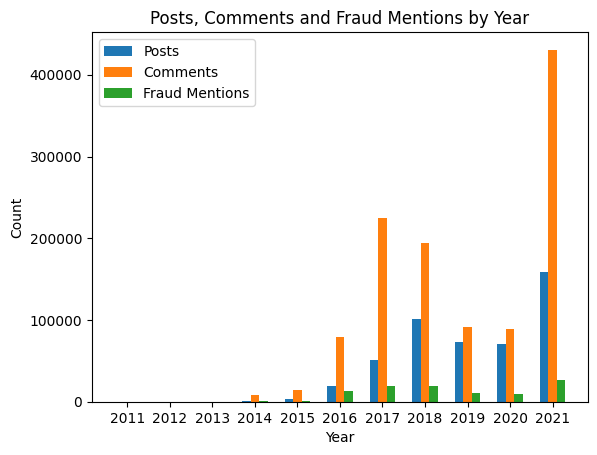

In [4]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(yearly_stats['Year']))
width = 0.2

plt.figure()

plt.bar(x - width, yearly_stats['Posts'], width)
plt.bar(x, yearly_stats['Comments'], width)
plt.bar(x + width, yearly_stats['Fraud Mentions'], width)

plt.xticks(x, yearly_stats['Year'])
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Posts, Comments and Fraud Mentions by Year')
plt.legend(['Posts', 'Comments', 'Fraud Mentions'])

plt.show()


##### Filter data

In [23]:
START_DATE = '2017-01-01'

reddit_daily_filtered = reddit_cleaned[reddit_daily['day'] >= START_DATE].copy()
print(f"Before filter: {len(reddit_daily):,} days")
print(f"After filter: {len(reddit_daily_filtered):,} days")
print(f"Date range: {reddit_daily_filtered['day'].min().date()} to {reddit_daily_filtered['day'].max().date()}")

Before filter: 2,886 days
After filter: 1,766 days
Date range: 2017-01-01 to 2021-11-01


## Calculate reddit_avg_sentiment Statistics

In [24]:
print("=== reddit_avg_sentiment Statistics ===")
print(reddit_daily_filtered['reddit_avg_sentiment'].describe())

=== reddit_avg_sentiment Statistics ===
count    1766.000000
mean        0.344497
std         0.054749
min         0.136119
25%         0.309283
50%         0.339228
75%         0.377626
max         0.552293
Name: reddit_avg_sentiment, dtype: float64


In [25]:
SENTIMENT_BASELINE = reddit_daily_filtered['reddit_avg_sentiment'].mean()
reddit_daily_filtered['reddit_sentiment_deviation'] = (reddit_daily_filtered['reddit_avg_sentiment'] - SENTIMENT_BASELINE)

## Select features

In [26]:
selected_features = [
    'day',
    'reddit_fraud_mention_ratio',
    'reddit_avg_sentiment',
    'reddit_sentiment_deviation',
    'reddit_total_activity'
]

reddit_daily_filtered = reddit_daily_filtered[selected_features].copy()

In [27]:
import os

output_dir = '../data/processed/reddit'
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, 'reddit_daily_cleaned.parquet')
reddit_daily_filtered.to_parquet(output_path, index=False)
print(f"Saved to: {output_path}")

csv_path = os.path.join(output_dir, 'reddit_daily_cleaned.csv')
reddit_daily_filtered.to_csv(csv_path, index=False)
print(f"Saved to: {csv_path}")

Saved to: ../data/processed/reddit\reddit_daily_cleaned.parquet
Saved to: ../data/processed/reddit\reddit_daily_cleaned.csv
